# 🏙️ Chicago Crime & Weather Analysis

---

## ❓ Question

> **Comment les conditions météorologiques influencent-elles la fréquence et la nature des crimes à Chicago ?**

---

## Introduction et Contexte

Chicago est l'une des villes les plus documentées au monde en matière de criminalité.
Dans ce projet, on croise les données criminelles (2001–2025) avec les
données météo de la ville pour tester une hypothèse classique en criminologie :
la *heat hypothesis* - par temps chaud, les gens sortent plus, les tensions montent,
les crimes augmentent.

L'hypothèse de la chaleur (*heat hypothesis*) suggère que les fortes températures augmentent l'agressivité et les interactions sociales, favorisant ainsi les crimes impulsifs. À l'inverse, le froid et les intempéries agiraient comme un **bouclier naturel**, réduisant les opportunités de crime.


Mais on va plus loin : on cherche à comprendre **quels crimes** réagissent à la météo,
**dans quels quartiers**, et **à quelles heures**.

---

## Plan du notebook

| Partie | Titre | Contenu |
|--------|-------|---------|
| **1** | Mise en place | Chargement, nettoyage, fusion des données |
| **2** | Portrait de la ville | Distribution des crimes, évolution 2001–2025, taux d'arrestation |
| **3** | Les Saisons du Crime | Saisonnalité, heatmap heure × mois, été vs hiver, jour de la semaine |
| **4** | La Météo et les Crimes | Température vs crimes, seuil critique, impulsifs vs calculés, effet pluie |
| **5** | Crimes, Météo et Inégalités | Portrait socioéconomique, effet par quartier, comparaison Ranson 2014 |
| **6** | Limites & Conclusion | Limites de l'analyse, conclusion finale |

---

# Partie 1 - Mise en place

Avant toute analyse, nous préparons l'environnement de travail : chargement des bibliothèques, import des données, premier regard sur leur structure, nettoyage et fusion.  

## 1.1 - Imports des bibliothèques


In [5]:
import sys
sys.path.append('..')


# Manipulation des données
import pandas as pd
import numpy as np

# Visualisation
import matplotlib.pyplot as plt
import seaborn as sns

# Style global
sns.set_theme(style="whitegrid", palette="muted")
plt.rcParams["figure.dpi"] = 110
pd.set_option("display.max_columns", 30)

print("Environnement prêt.")

Environnement prêt.


## 1.2 - Chargement du dataset des crimes

Le dataset des crimes de Chicago est publié par la ville sur [data.cityofchicago.org](https://data.cityofchicago.org/stories/s/Crimes-2001-to-present-Dashboard/5cd6-ry5g).  
Il recense **chaque incident criminel** depuis 2001 : type de crime, date, lieu, quartier, et si une arrestation a été effectuée.

Le fichier complet dépasse plusieurs millions de lignes. Pour garder un temps de calcul raisonnable tout en conservant la **représentativité statistique**, nous procédons à un **échantillonnage aléatoire de 500 000 observations**.


In [6]:
# ── BLOC A N'EXECUTER QU'UNE SEULE FOIS ───
# Lecture par morceaux

# chunks = []
# chunk_size = 100_000

# for chunk in pd.read_csv("chicago_crimes.csv", chunksize=chunk_size, low_memory=False):
#     chunk["Date"] = pd.to_datetime(
#         chunk["Date"],
#         format="%m/%d/%Y %I:%M:%S %p",
#         errors="coerce"
#     )
#     chunk = chunk[chunk["Date"].dt.year.between(2001, 2025)]
#     chunks.append(chunk)

# df_raw = pd.concat(chunks, ignore_index=True)

# # Echantillonnage reproductible (random_state fixe)
# df_crime_sample = df_raw.sample(n=500_000, random_state=42).reset_index(drop=True)
# df_crime_sample.to_csv("chicago_crimes_500k.csv", index=False)
# print("Echantillon sauvegarde : chicago_crimes_500k.csv")

> **Note :** La cellule ci-dessus ne doit être exécutée qu'une seule fois pour générer l'échantillon.  
> Toutes les analyses suivantes chargent directement `chicago_crimes_500k.csv`.


In [7]:
# Chargement de l'echantillon sauvegardé
df_crime = pd.read_csv("../data/chicago_crimes_500k.csv", low_memory=False)

df_crime["Date"] = pd.to_datetime(df_crime["Date"], errors="coerce")

print(f"Dataset crimes : {df_crime.shape[0]:,} lignes - {df_crime.shape[1]} colonnes")
print(f"Periode       : {df_crime['Date'].dt.year.min()} - {df_crime['Date'].dt.year.max()}")

df_crime.head(3)


Dataset crimes : 500,000 lignes - 22 colonnes
Periode       : 2001 - 2025


,ID,Case Number,Date,Block,IUCR,Primary Type,Description,Location Description,Arrest,Domestic,Beat,District,Ward,Community Area,FBI Code,X Coordinate,Y Coordinate,Year,Updated On,Latitude,Longitude,Location
0,6346930,HP433693,2008-07-05 01:35:12,010XX W BERWYN AVE,0454,BATTERY,AGG PO HANDS NO/MIN INJURY,STREET,False,False,2023,20.0,48.0,77.0,08B,1168465.0,1935378.0,2008,02/28/2018 03:56:25 PM,41.978210,-87.655839,"(41.978209696, -87.655838514)"
1,1658580,G444951,2001-07-28 17:30:00,068XX S ROCKWELL ST,1310,CRIMINAL DAMAGE,TO PROPERTY,RESIDENCE,False,False,832,8.0,NaN,NaN,14,1160258.0,1859243.0,2001,08/17/2015 03:03:40 PM,41.769462,-87.688124,"(41.769462259, -87.688124484)"
2,3295194,HK318712,2004-04-22 20:20:00,060XX S RACINE AVE,0460,BATTERY,SIMPLE,CTA BUS,True,False,713,7.0,16.0,67.0,08B,1169357.0,1864637.0,2004,02/28/2018 03:56:25 PM,41.784072,-87.654616,"(41.784071906, -87.654615587)"


## 1.3 - Chargement du dataset météorologique

Les données météo proviennent de **Open météo**. 
Ce fichier est de taille modérée et peut être chargé intégralement.


In [8]:
df_meteo = pd.read_csv("../data/chicago_weather.csv")

df_meteo["time"] = pd.to_datetime(df_meteo["time"], errors="coerce")

print(f"Dataset meteo : {df_meteo.shape[0]:,} lignes - {df_meteo.shape[1]} colonnes")
print(f"Periode      : {df_meteo['time'].dt.year.min()} - {df_meteo['time'].dt.year.max()}")

df_meteo.head(3)


Dataset meteo : 9,131 lignes - 5 colonnes
Periode      : 2001 - 2025


,time,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm)
0,2001-01-01,-7.5,-5.1,-9.2,0.0
1,2001-01-02,-11.2,-7.3,-15.1,0.0
2,2001-01-03,-8.9,-2.7,-12.1,0.2


## 1.4 - Nettoyage des données

Nous vérifions la qualité des deux datasets :  
- **Valeurs manquantes** - à traiter ou exclure selon leur volume et leur impact analytique  
- **Doublons** - à supprimer pour éviter les biais de comptage  
- **Variables inutiles** - nous ne conservons que les colonnes pertinentes pour l'analyse  

## Sélection des colonnes utiles

On ne garde que les colonnes dont on a besoin pour notre analyse.
Inutile de travailler avec toutes les variables du dataset.

Les variables pertinentes sont : 

- Date : permettra de relier chaque crime aux conditions météorologiques correspondantes.

- Primary Type : indique la catégorie principale du crime.

- Description : fournit une description plus précise du crime.

- Arrest : indique si une arrestation a eu lieu après le crime.

- Community Area : correspond à une zone administrative de la ville.

- Latitude et Longitude : correspondent aux coordonnées géographiques du crime.

Après cette sélection, le dataset est réduit à un ensemble de variables
plus pertinent pour l’analyse.

In [9]:
#Sélection des colonnes pertinentes
cols_crime = [
    "Date", "Primary Type", "Description",
    "Arrest", "Community Area", "Latitude", "Longitude"
]

df_crime = df_crime[cols_crime].copy()
df_crime.head(3)

,Date,Primary Type,Description,Arrest,Community Area,Latitude,Longitude
0,2008-07-05 01:35:12,BATTERY,AGG PO HANDS NO/MIN INJURY,False,77.0,41.978210,-87.655839
1,2001-07-28 17:30:00,CRIMINAL DAMAGE,TO PROPERTY,False,NaN,41.769462,-87.688124
2,2004-04-22 20:20:00,BATTERY,SIMPLE,True,67.0,41.784072,-87.654616


## Nettoyage des données

Avant toute analyse, on vérifie la qualité du dataset :
valeurs manquantes, doublons, types de variables.

In [10]:
df_crime.isnull().sum().sort_values(ascending=False).head(10)

Community Area    36134
Latitude           5533
Longitude          5533
Description           0
Primary Type          0
Date                  0
Arrest                0
dtype: int64

- `Community Area` : 36 134 valeurs manquantes - on les garde pour l'instant,
  on les exclura uniquement lors des analyses par quartier.
- `Latitude / Longitude` : 5 533 manquantes - pareil, exclues uniquement pour les cartes.
- `Date`, `Primary Type`, `Arrest`, `Description` : aucune valeur manquante

Pas besoin de supprimer des lignes ici.

## Suppression des doublons

In [11]:
before = len(df_crime)
df_crime.drop_duplicates(inplace=True)
after = len(df_crime)

print(f"Lignes avant : {before:,}")
print(f"Lignes après : {after:,}")
print(f"Doublons supprimés : {before - after:,}")

Lignes avant : 500,000
Lignes après : 499,859
Doublons supprimés : 141


141 doublons supprimés sur 500 000 lignes, soit 0.03% du dataset.
Il nous reste **499 859 observations** pour la suite.

## Extraction des variables temporelles

On extrait depuis la colonne `Date` les variables dont on aura besoin :
l'année, le mois, l'heure et le jour de la semaine.

In [12]:
df_crime["Date"] = pd.to_datetime(df_crime["Date"], errors="coerce")

df_crime["year"]      = df_crime["Date"].dt.year
df_crime["month"]     = df_crime["Date"].dt.month
df_crime["hour"]      = df_crime["Date"].dt.hour
df_crime["weekday"]   = df_crime["Date"].dt.dayofweek  # 0 = Lundi, 6 = Dimanche
df_crime["date_only"] = df_crime["Date"].dt.normalize()

df_crime.head(3)

,Date,Primary Type,Description,Arrest,Community Area,Latitude,Longitude,year,month,hour,weekday,date_only
0,2008-07-05 01:35:12,BATTERY,AGG PO HANDS NO/MIN INJURY,False,77.0,41.978210,-87.655839,2008,7,1,5,2008-07-05
1,2001-07-28 17:30:00,CRIMINAL DAMAGE,TO PROPERTY,False,NaN,41.769462,-87.688124,2001,7,17,5,2001-07-28
2,2004-04-22 20:20:00,BATTERY,SIMPLE,True,67.0,41.784072,-87.654616,2004,4,20,3,2004-04-22


## Vérification des valeurs manquantes - Météo


In [13]:
df_meteo.isnull().sum()


time                        0
temperature_2m_mean (°C)    0
temperature_2m_max (°C)     0
temperature_2m_min (°C)     0
precipitation_sum (mm)      0
dtype: int64

Aucune valeur manquante dans le dataset météo

Les colonnes disponibles :
- `time` : la date
- `temperature_2m_mean (°C)` : température moyenne journalière
- `temperature_2m_max (°C)` : température maximale
- `temperature_2m_min (°C)` : température minimale
- `precipitation_sum (mm)` : précipitations journalières

## 1.5 - Fusion des deux datasets

On effectue une jointure sur la date : chaque crime reçoit les conditions
météo du jour où il a été commis.

In [14]:
# Renommage pour harmoniser la clé de jointure
df_meteo = df_meteo.rename(columns={"time": "date_only"})
df_meteo["date_only"] = pd.to_datetime(df_meteo["date_only"])

# Fusion
df = df_crime.merge(df_meteo, on="date_only", how="left")

print(f"Dataset fusionné : {df.shape[0]:,} lignes - {df.shape[1]} colonnes")
df.head(3)

Dataset fusionné : 499,859 lignes - 16 colonnes


,Date,Primary Type,Description,Arrest,Community Area,Latitude,Longitude,year,month,hour,weekday,date_only,temperature_2m_mean (°C),temperature_2m_max (°C),temperature_2m_min (°C),precipitation_sum (mm)
0,2008-07-05 01:35:12,BATTERY,AGG PO HANDS NO/MIN INJURY,False,77.0,41.978210,-87.655839,2008,7,1,5,2008-07-05,21.2,24.5,18.2,0.0
1,2001-07-28 17:30:00,CRIMINAL DAMAGE,TO PROPERTY,False,NaN,41.769462,-87.688124,2001,7,17,5,2001-07-28,23.6,26.1,21.2,0.8
2,2004-04-22 20:20:00,BATTERY,SIMPLE,True,67.0,41.784072,-87.654616,2004,4,20,3,2004-04-22,8.4,12.4,6.1,0.0


## Synthèse - Partie 1

| Dataset | Lignes | Colonnes | Valeurs manquantes |
|---------|--------|----------|--------------------|
| Crimes (après nettoyage) | 499 859 | 11 | Community Area, Lat/Long seulement |
| Météo | 8 766 | 5 | Aucune |
| **Dataset fusionné** | **499 859** | **16** | - |

Chaque crime est associé aux conditions météo exactes du jour où il s'est produit.
On peut maintenant commencer à explorer les données.

---

# Partie 2 - Portrait de la ville

Explorons les types de crimes les plus courants et l'évolution du taux de criminalité au cours des 20 dernières années dans la ville de Chicago.  
Ce premier acte nous donne une base solide pour interpréter
tout ce qui suit.

## 2.1 - Quels sont les crimes les plus fréquents ?


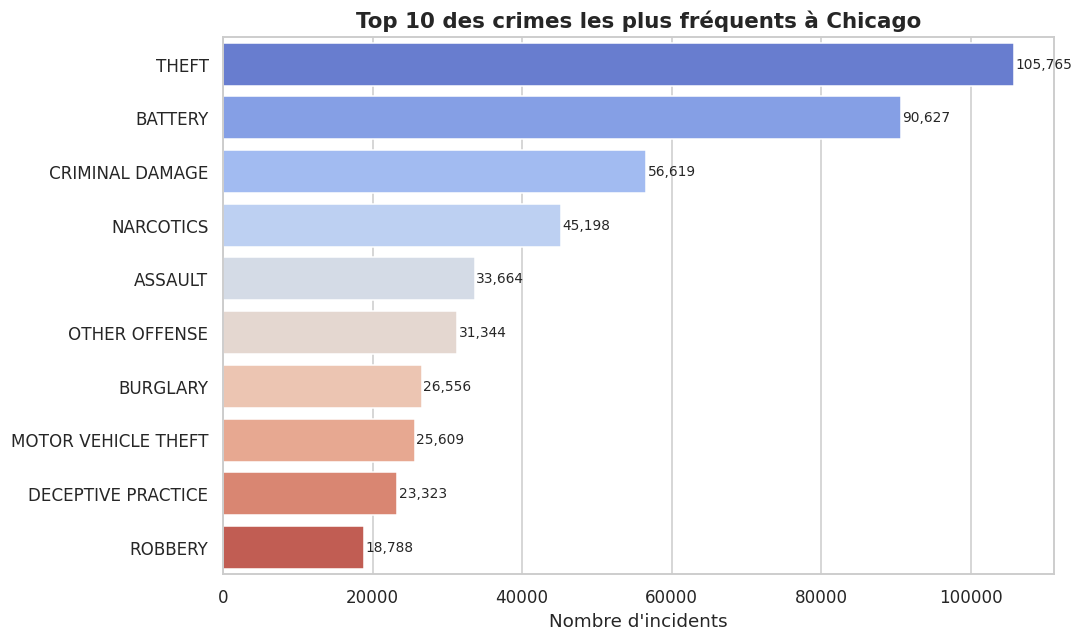

In [15]:
top_crimes = (df["Primary Type"]
              .value_counts()
              .head(10)
              .reset_index())
top_crimes.columns = ["Type de crime", "Nombre"]

fig, ax = plt.subplots(figsize=(10, 6))
sns.barplot(data=top_crimes, x="Nombre", y="Type de crime",
            hue="Type de crime", palette="coolwarm", legend=False, ax=ax)

ax.set_title("Top 10 des crimes les plus fréquents à Chicago", fontsize=14, fontweight="bold")
ax.set_xlabel("Nombre d'incidents")
ax.set_ylabel("")

for i, row in top_crimes.iterrows():
    ax.text(row["Nombre"] + 200, i, f"{row['Nombre']:,}", va="center", fontsize=9)

plt.tight_layout()
plt.show()

### Interprétation

Le **THEFT** (vol) domine largement avec 105 765 incidents, suivi de
**BATTERY** (coups et blessures) avec 90 627 cas. Ces deux crimes représentent
à eux seuls près de 40% de notre échantillon.

Ce classement est important pour la suite :
- **THEFT, BURGLARY, MOTOR VEHICLE THEFT** sont des crimes **calculés** -
  l'auteur choisit son moment, planifie son acte.
- **BATTERY, ASSAULT, ROBBERY** sont des crimes **impulsifs** -
  ils naissent d'une confrontation, d'une tension, d'un moment.

## 2.2 - Évolution annuelle des crimes (2001–2025)

Est-ce que Chicago est devenue plus ou moins dangereuse au fil des années ?


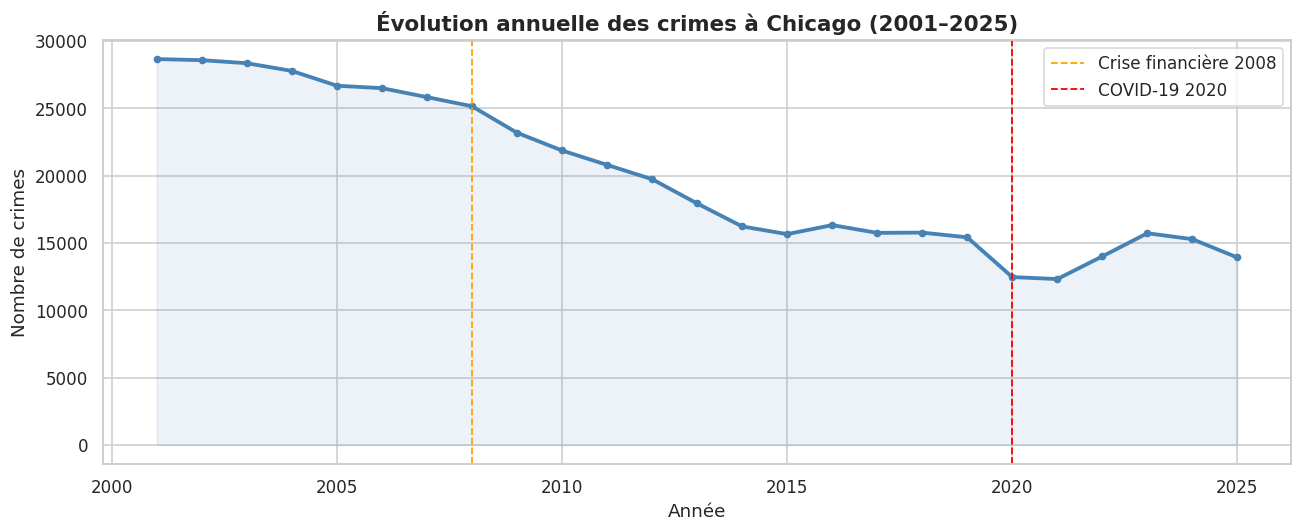

In [16]:
crimes_by_year = df.groupby("year").size().reset_index(name="Nombre")

fig, ax = plt.subplots(figsize=(12, 5))
ax.plot(crimes_by_year["year"], crimes_by_year["Nombre"],
        color="steelblue", linewidth=2.5, marker="o", markersize=4)

ax.fill_between(crimes_by_year["year"], crimes_by_year["Nombre"],
                alpha=0.1, color="steelblue")

# Annotations événements marquants
ax.axvline(x=2008, color="orange", linestyle="--", linewidth=1.2, label="Crise financière 2008")
ax.axvline(x=2020, color="red", linestyle="--", linewidth=1.2, label="COVID-19 2020")

ax.set_title("Évolution annuelle des crimes à Chicago (2001–2025)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Année")
ax.set_ylabel("Nombre de crimes")
ax.legend()

plt.tight_layout()
plt.show()

### Interprétation

La tendance générale est claire : **Chicago a enregistré deux fois moins de crimes
en 2025 qu'en 2001**.

Deux moments retiennent l'attention :

- **2008 - Crise financière** : la criminalité ne remonte pas après la crise. La baisse continue.
  Cela suggère que d'autres facteurs structurels (politiques publiques,
  démographie) jouent un rôle plus fort que la situation économique.

- **2020 - COVID-19** : on observe une **chute nette**, le point le plus bas
  de toute la série. Les confinements ont vidé les rues, supprimant mécaniquement
  les opportunités de crime. C'est un cas de ce qu'on observera dans la partie 3 avec la météo : quand les gens restent chez eux, les crimes baissent.
  Après 2020, une légère remontée est visible - un effet de "rattrapage" post-confinement 🙂.


## 2.3 - Taux d'arrestation par type de crime

Tous les crimes ne mènent pas à une arrestation.
Ce taux en dit long sur la visibilité et la gravité perçue de chaque crime.

Taux d'arrestation global : 25.1%


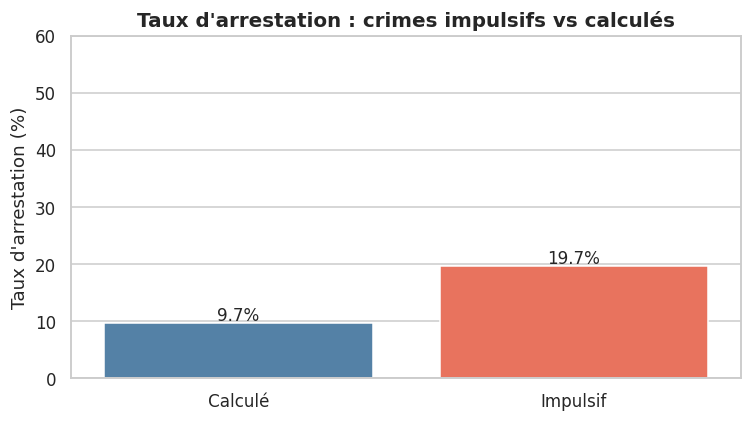

In [17]:
# Taux d'arrestation global
taux_global = df["Arrest"].map({True: 1, False: 0, "true": 1, "false": 0}).mean() * 100
print(f"Taux d'arrestation global : {taux_global:.1f}%")

# Impulsifs vs Calculés
impulsifs  = ["BATTERY", "ASSAULT", "HOMICIDE", "ROBBERY"]
calcules   = ["THEFT", "BURGLARY", "MOTOR VEHICLE THEFT", "DECEPTIVE PRACTICE"]

df["crime_type"] = "Autre"
df.loc[df["Primary Type"].isin(impulsifs), "crime_type"] = "Impulsif"
df.loc[df["Primary Type"].isin(calcules),  "crime_type"] = "Calculé"

taux = (df[df["crime_type"] != "Autre"]
        .groupby("crime_type")["Arrest"]
        .apply(lambda x: x.map({True: 1, False: 0, "true": 1, "false": 0}).mean() * 100)
        .reset_index())
taux.columns = ["Type", "Taux d'arrestation (%)"]

fig, ax = plt.subplots(figsize=(7, 4))
sns.barplot(data=taux, x="Type", y="Taux d'arrestation (%)",
            hue="Type", palette={"Impulsif": "tomato", "Calculé": "steelblue"},
            legend=False, ax=ax)

ax.set_title("Taux d'arrestation : crimes impulsifs vs calculés",
             fontsize=13, fontweight="bold")
ax.set_ylabel("Taux d'arrestation (%)")
ax.set_xlabel("")
ax.set_ylim(0, 60)

for p in ax.patches:
    ax.text(p.get_x() + p.get_width()/2, p.get_height() + 0.5,
            f"{p.get_height():.1f}%", ha="center", fontsize=11)

plt.tight_layout()
plt.show()

### Interprétation

Le taux d'arrestation global à Chicago est de seulement **25.1%** -
3 crimes sur 4 ne mènent à aucune arrestation.

La comparaison impulsifs vs calculés :
- **Crimes impulsifs : 19.7%** - ils se produisent en public, avec une victime
  présente, des témoins potentiels. Pourtant le taux reste faible.
- **Crimes calculés : 9.7%** - deux fois moins d'arrestations. Normal :
  le cambrioleur ou le voleur planifie son acte, choisit son moment,
  laisse peu de traces.

> Ce résultat pose une question importante pour la suite :
> si les crimes impulsifs sont plus visibles et plus faciles à résoudre,
> ce sont aussi ceux qui réagissent le plus à la météo.
> La chaleur augmente les crimes impulsifs - et ce sont justement
> ceux qu'on arrête le plus. La météo influence donc indirectement
> le taux d'arrestation global de Chicago.

---

## Synthèse - Partie 2

Chicago sur 20 ans, c'est une ville qui a **profondément changé** :
deux fois moins de crimes en 2025 qu'en 2001, malgré sa réputation.

Trois choses à retenir pour la suite :

1. **THEFT et BATTERY dominent** - le vol et les coups représentent
   à eux seuls 40% des incidents. Ce sont deux crimes de nature opposée :
   l'un calculé, l'autre impulsif.

2. **Le COVID a prouvé quelque chose d'important** : quand les gens
   restent chez eux, les crimes chutent. Ce mécanisme, on va le retrouver
   avec la météo - le froid et la pluie ont le même effet que le confinement.

3. **Les crimes impulsifs s'arrêtent deux fois plus** que les crimes calculés.
   Ce sont aussi ceux qui réagissent le plus à la chaleur.

---

# Partie 3 - Les Saisons du Crime

Les crimes ne sont pas distribués uniformément dans l'année, ni dans la semaine, ni dans la journée.

Cette partie explore ces patterns temporels et prépare le terrain
pour introduire la météo.

## 3.1 - Volume mensuel moyen des crimes

Y a-t-il des mois plus dangereux que d'autres ?

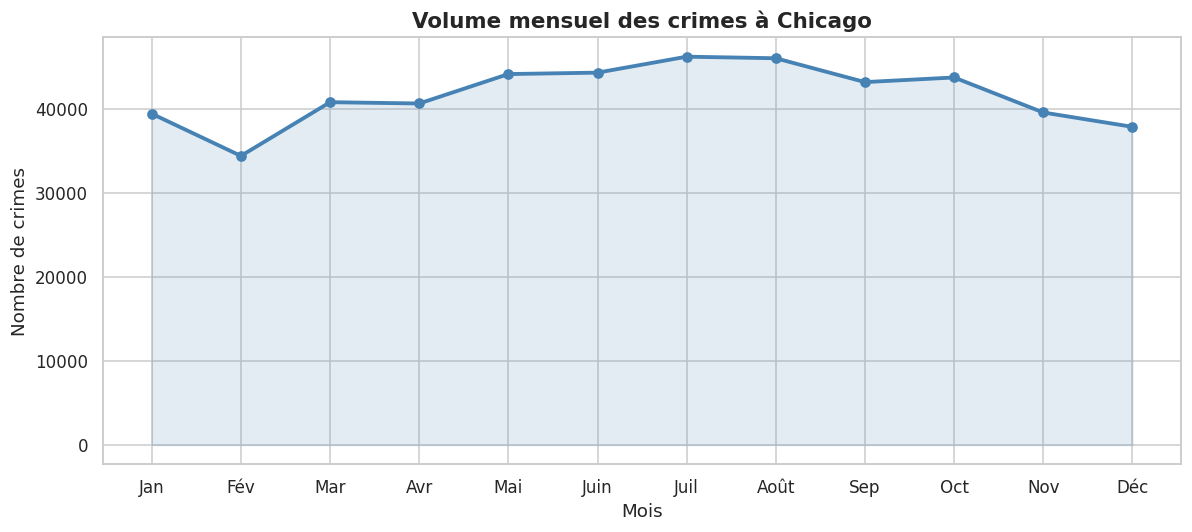

In [18]:
# Crimes regroupés par mois
monthly = (df.groupby("month")
             .size()
             .reset_index(name="Nombre"))

mois_labels = ["Jan", "Fév", "Mar", "Avr", "Mai", "Juin",
               "Juil", "Août", "Sep", "Oct", "Nov", "Déc"]

fig, ax = plt.subplots(figsize=(11, 5))
ax.plot(monthly["month"], monthly["Nombre"],
        color="steelblue", linewidth=2.5, marker="o", markersize=6)
ax.fill_between(monthly["month"], monthly["Nombre"], alpha=0.15, color="steelblue")

ax.set_xticks(range(1, 13))
ax.set_xticklabels(mois_labels)
ax.set_title("Volume mensuel des crimes à Chicago", fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Nombre de crimes")

plt.tight_layout()
plt.show()

### Interprétation
On constate : 

- **Février est le mois le plus calme** - le froid extrême de Chicago
  vide littéralement les rues. Moins de monde dehors = moins d'interactions
  = moins de conflits et d'opportunités de crime.

- **Juillet–Août sont les mois les plus criminogènes** - près de 30% de crimes
  en plus qu'en février. L'été ramène les gens dans l'espace public,
  les soirées s'étirent, les tensions montent.

> Ce graphique ne prouve pas encore que c'est la météo qui explique
> ces variations - ça pourrait être les vacances scolaires, les événements etc.

## 3.2 - Heure × Mois

À quelle heure les crimes surviennent-ils selon la saison ?

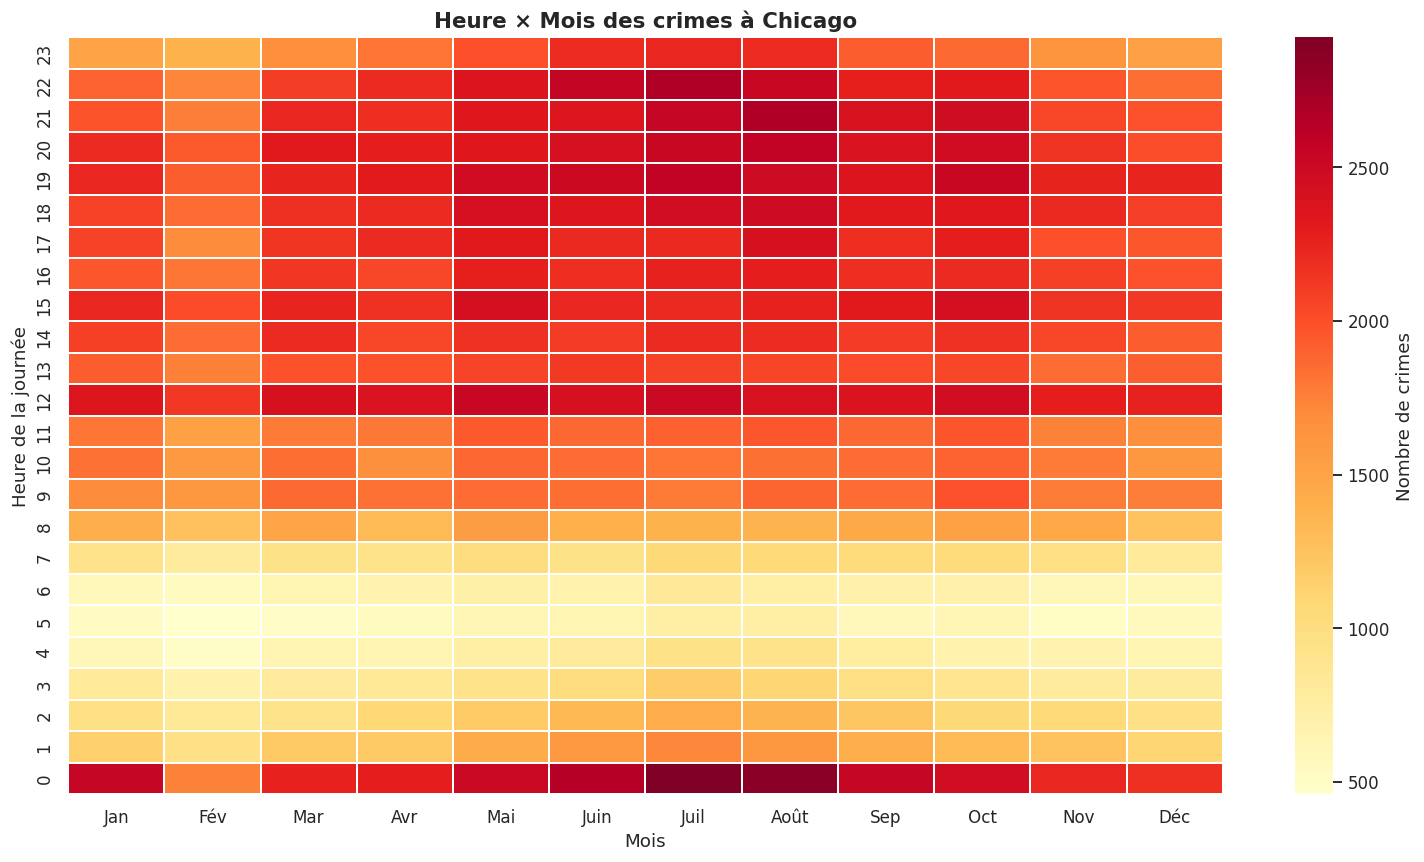

In [19]:
heatmap_data = (df.groupby(["hour", "month"])
                  .size()
                  .reset_index(name="Nombre"))

heatmap_pivot = heatmap_data.pivot(index="hour", columns="month", values="Nombre")
heatmap_pivot.columns = mois_labels

fig, ax = plt.subplots(figsize=(14, 8))
sns.heatmap(heatmap_pivot, cmap="YlOrRd", linewidths=0.3,
            linecolor="white", annot=False, ax=ax,
            cbar_kws={"label": "Nombre de crimes"})

ax.set_title("Heure × Mois des crimes à Chicago",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Mois")
ax.set_ylabel("Heure de la journée")
ax.invert_yaxis()

plt.tight_layout()
plt.show()

### Interprétation

**Ce qu'on observe :**

- **Minuit (heure 0) en juillet–août** : la case la plus foncée de toute la matrice.
  C'est le pic absolu - les nuits d'été à Chicago sont les plus dangereuses.

- **La tranche 12h–20h est uniformément rouge** toute l'année.
  Ce sont les heures d'activité humaine maximale - logiquement,
  les crimes suivent la présence des gens dans la rue.

- **Les heures 2h–7h sont les plus calmes**, quelle que soit la saison.
  La ville dort, les rues sont vides.

- **En hiver (Jan–Fév), même les heures de pointe sont moins intenses** -
  le froid compresse l'activité humaine, et avec elle, la criminalité.

> Ce n'est pas donc juste la température qui compte,
> c'est ce qu'elle fait faire aux gens. En été, ils sortent plus tard,
> restent dehors plus longtemps. La météo reconfigure les rythmes de vie,
> et les crimes suivent ces rythmes.

## 3.3 - Été vs Hiver : quels crimes changent le plus ?

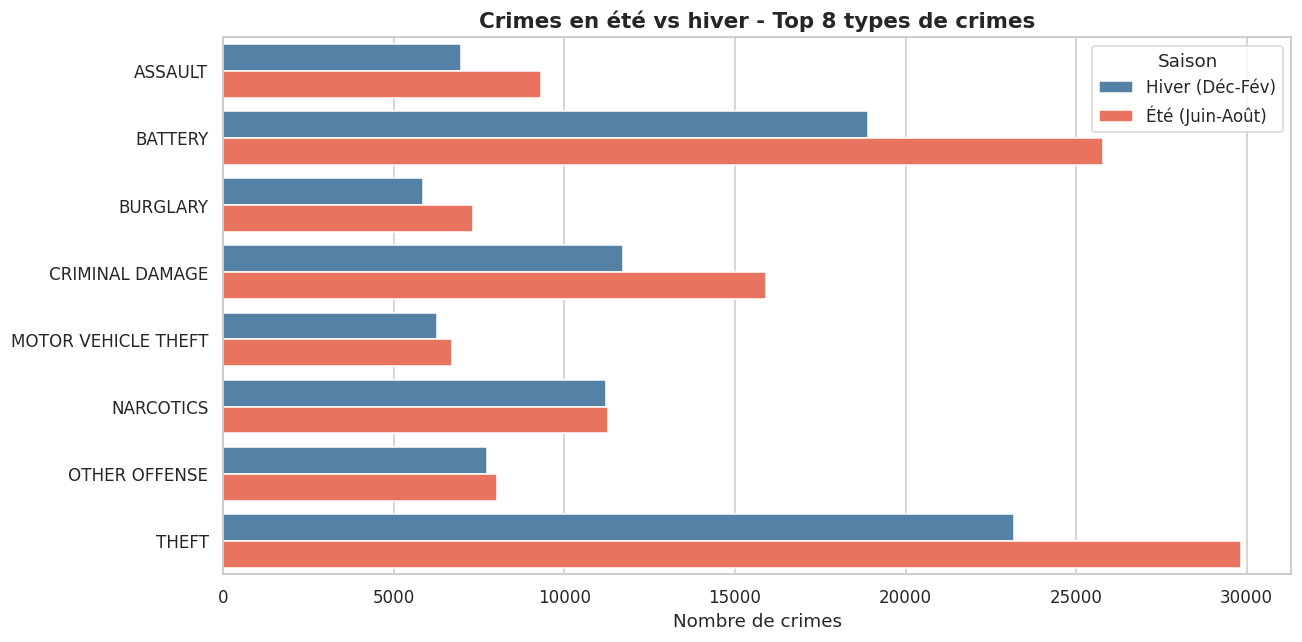

In [20]:
df["saison"] = df["month"].apply(
    lambda m: "Été (Juin-Août)" if m in [6, 7, 8] else
              ("Hiver (Déc-Fév)" if m in [12, 1, 2] else None)
)

saison_df = df[df["saison"].notna()]

top8 = df["Primary Type"].value_counts().head(8).index
saison_top = saison_df[saison_df["Primary Type"].isin(top8)]

saison_count = (saison_top.groupby(["Primary Type", "saison"])
                           .size()
                           .reset_index(name="Nombre"))

fig, ax = plt.subplots(figsize=(12, 6))
sns.barplot(data=saison_count, x="Nombre", y="Primary Type",
            hue="saison", palette={"Été (Juin-Août)": "tomato",
                                   "Hiver (Déc-Fév)": "steelblue"},
            ax=ax)

ax.set_title("Crimes en été vs hiver - Top 8 types de crimes",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Nombre de crimes")
ax.set_ylabel("")
ax.legend(title="Saison")

plt.tight_layout()
plt.show()

### Interprétation

Ce graphique confirme et nuance ce qu'on observait sur la courbe mensuelle.
**Tous les crimes n'augmentent pas de la même façon en été.**

**Les crimes qui explosent en été :**
- **BATTERY** : les coups et blessures sont typiquement des crimes de confrontation,
  favorisés par les soirées dehors, la chaleur qui accélère les tensions.
- **ASSAULT** : même tendance.
- **THEFT** : augmente aussi en été; plus de monde dans les rues,
  plus de cibles potentielles pour les pickpockets.

**Les crimes qui résistent à la saisonnalité :**
- **MOTOR VEHICLE THEFT** : quasi identique été et hiver.
  Une voiture se vole de nuit, dans un parking, peu importe la température.
  C'est un crime calculé, indépendant de la présence humaine dans la rue.
- **NARCOTICS** : pratiquement stable. Le trafic de drogue ne s'arrête
  pas en hiver.

> La météo affecte les comportements humains spontanés,
> pas les activités criminelles organisées et planifiées.

## 3.4 - Crimes par jour de la semaine

Est-ce que le weekend change quelque chose ?

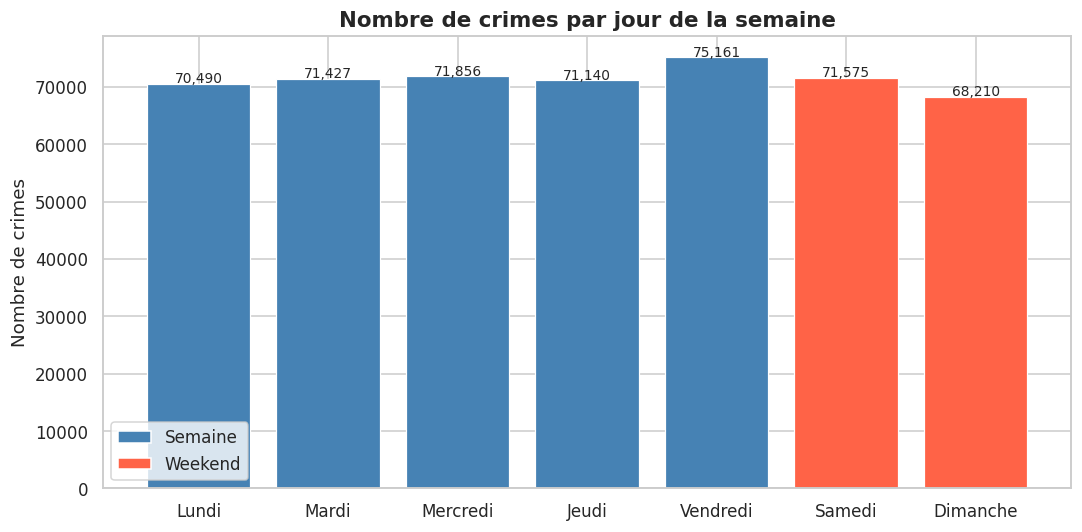

In [21]:
jours_labels = ["Lundi", "Mardi", "Mercredi", "Jeudi", "Vendredi", "Samedi", "Dimanche"]

crimes_by_day = (df.groupby("weekday")
                   .size()
                   .reset_index(name="Nombre"))
crimes_by_day["Jour"] = jours_labels

colors = ["steelblue" if i < 5 else "tomato" for i in range(7)]

fig, ax = plt.subplots(figsize=(10, 5))
bars = ax.bar(crimes_by_day["Jour"], crimes_by_day["Nombre"],
              color=colors, edgecolor="white", linewidth=0.8)

ax.set_title("Nombre de crimes par jour de la semaine",
             fontsize=14, fontweight="bold")
ax.set_ylabel("Nombre de crimes")
ax.set_xlabel("")

for bar in bars:
    ax.text(bar.get_x() + bar.get_width()/2, bar.get_height() + 200,
            f"{int(bar.get_height()):,}", ha="center", fontsize=9)

# Légendes
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="steelblue", label="Semaine"),
                   Patch(facecolor="tomato", label="Weekend")]
ax.legend(handles=legend_elements)

plt.tight_layout()
plt.show()

### Interprétation

Contrairement à ce qu'on pourrait attendre, **le weekend n'est pas
significativement plus criminel que la semaine**.

Les chiffres sont remarquablement stables : entre 68 000 et 75 000
crimes par jour, tous les jours de la semaine.

**Ce qui ressort quand même :**
- **Vendredi est le jour le plus criminel** (75 161) - c'est la jonction
  entre la semaine et le weekend. Les gens sortent, les bars se remplissent,
  les conflits augmentent en fin de journée.
- **Dimanche est le plus calme** (68 210) moins d'activité dans l'espace public.

> **Le résultat contre-intuitif ici est important** : on aurait pu penser
> que le weekend concentre les crimes. Ce n'est pas le cas à Chicago.
> Cela suggère que la criminalité est davantage liée aux **conditions
> météo et saisonnières** qu'au rythme hebdomadaire.


---

## Synthèse - Partie 3

1. **La saisonnalité est réelle** : juillet–août concentrent 30% de crimes
   de plus que février.

2. **Les nuits d'été sont le vrai point chaud** : le pic absolu est minuit en juillet. La chaleur prolonge la présence
   humaine dans la rue jusqu'au cœur de la nuit.

3. **Tous les crimes ne réagissent pas pareil** : BATTERY et ASSAULT
   explosent en été, MOTOR VEHICLE THEFT et NARCOTICS restent stables.

4. **Le weekend n'est pas plus dangereux** :  résultat contre-intuitif
   qui renforce l'idée que c'est la météo, plus que le calendrier social,
   qui structure la criminalité à Chicago.

Ces observations nous donnent des hypothèses précises à tester
dans la partie 4 : est-ce vraiment la température qui explique tout ça ?

---

# Partie 4 - La météo et les crimes

On croise les données météo avec les crimes. 
La partie 3 a montré que les crimes suivent le calendrier saisonnier.
Mais est-ce vraiment la **température** qui explique ça, ou simplement
le fait que c'est l'été ?

Un jour de mars à 20°C produit-il autant de crimes qu'un jour de juillet
à 20°C ? C'est cette question précise qu'on va répondre ici en isolant
le facteur température du facteur saison

## 4.1 - Température vs nombre de crimes (vue globale)

Est-ce qu'une journée plus chaude = plus de crimes ?

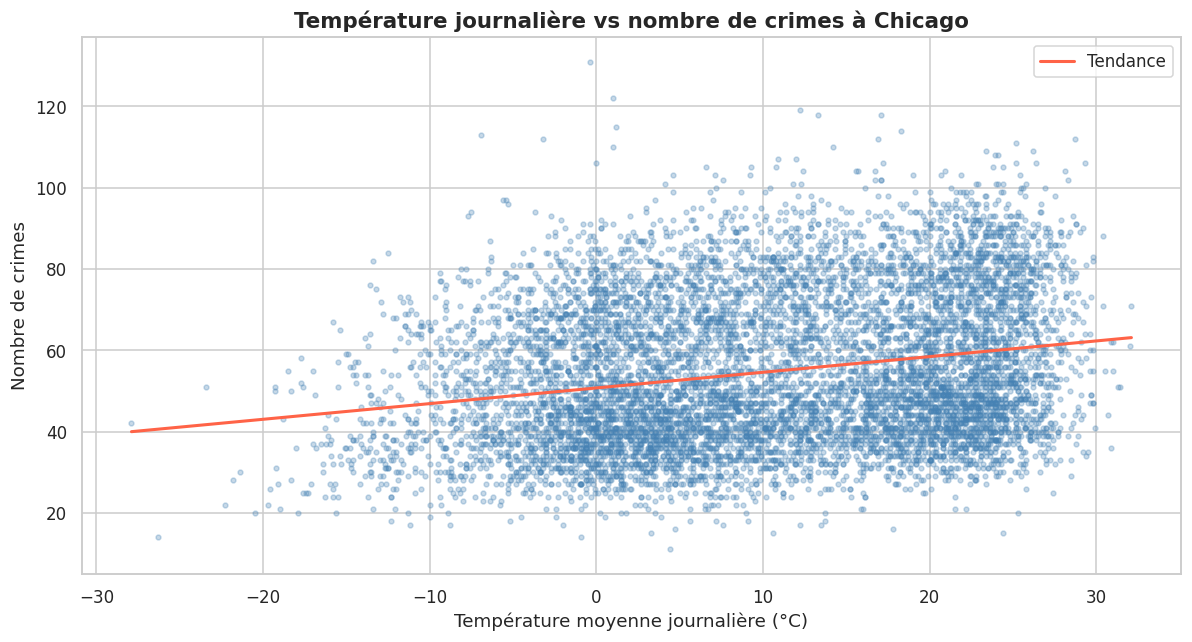

In [22]:
# Nombre de crimes par jour + température moyenne
daily = (df.groupby("date_only")
           .agg(
               nb_crimes=("Primary Type", "count"),
               temp=("temperature_2m_mean (°C)", "mean")
           )
           .reset_index()
           .dropna())

fig, ax = plt.subplots(figsize=(11, 6))
ax.scatter(daily["temp"], daily["nb_crimes"],
           alpha=0.3, color="steelblue", s=10)

# Ligne de tendance
z = np.polyfit(daily["temp"], daily["nb_crimes"], 1)
p = np.poly1d(z)
x_line = np.linspace(daily["temp"].min(), daily["temp"].max(), 200)
ax.plot(x_line, p(x_line), color="tomato", linewidth=2, label="Tendance")

ax.set_title("Température journalière vs nombre de crimes à Chicago",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Température moyenne journalière (°C)")
ax.set_ylabel("Nombre de crimes")
ax.legend()

plt.tight_layout()
plt.show()

### Interprétation

La ligne de tendance est sans ambiguïté : **plus il fait chaud,
plus il y a de crimes**. C'est la confirmation visuelle de la heat& hypothesis.

- **La corrélation est réelle mais modérée** - le nuage de points est très dispersé.
  Par -10°C on peut avoir 80 crimes, et par +25°C on peut en avoir 30.
  La température n'est pas le seul facteur, c'est un facteur parmi d'autres.

- **Les extrêmes froids réduisent le plancher** : en dessous de -10°C,
  les jours avec peu de crimes sont beaucoup plus fréquents.
  Le grand froid de Chicago agit comme un couvre-feu.

> La tendance est là, mais elle est bruitée. On va maintenant
> la préciser avec les tranches de température pour trouver
> le **seuil critique**.

## 4.2 - Le seuil critique : crimes par tranche de 5°C

Existe-t-il une température précise à partir de laquelle
les crimes augmentent nettement ?

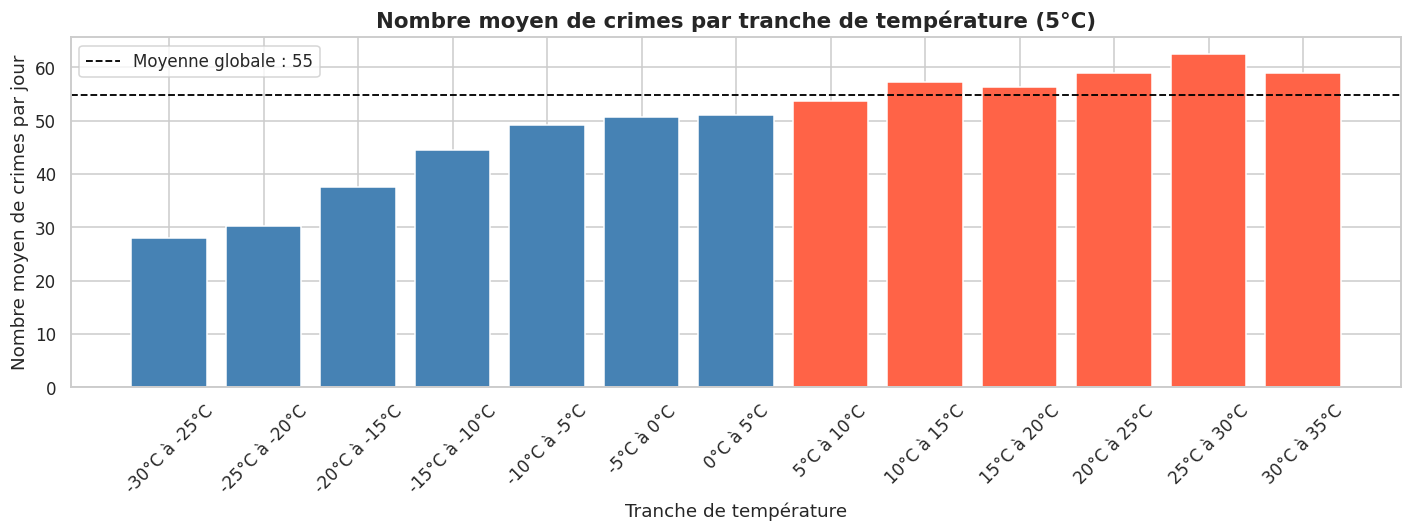

In [23]:
# Création des tranches de 5°C
bins   = range(-30, 40, 5)
labels = [f"{i}°C à {i+5}°C" for i in range(-30, 35, 5)]

daily["tranche"] = pd.cut(daily["temp"], bins=bins, labels=labels)

seuil = (daily.groupby("tranche", observed=True)["nb_crimes"]
              .mean()
              .reset_index())
seuil.columns = ["Tranche", "Moyenne crimes"]

fig, ax = plt.subplots(figsize=(13, 5))
bars = ax.bar(seuil["Tranche"], seuil["Moyenne crimes"],
              color=["steelblue" if i < 7 else "tomato"
                     for i in range(len(seuil))],
              edgecolor="white")

ax.set_title("Nombre moyen de crimes par tranche de température (5°C)",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tranche de température")
ax.set_ylabel("Nombre moyen de crimes par jour")
ax.tick_params(axis="x", rotation=45)

# Ligne de référence moyenne globale
moyenne = daily["nb_crimes"].mean()
ax.axhline(y=moyenne, color="black", linestyle="--",
           linewidth=1.2, label=f"Moyenne globale : {moyenne:.0f}")
ax.legend()

plt.tight_layout()
plt.show()

### Interprétation
**Ce qu'on observe :**

- **En dessous de 0°C** : les crimes sont nettement sous la moyenne globale.
  Par grand froid (-25°C à -30°C), la ville enregistre seulement 28 crimes
  par jour en moyenne.

- **Entre 0°C et 5°C** : on est encore sous la moyenne.

- **À partir de 5°C** : on franchit la moyenne globale de 55 crimes/jour.

- **25°C à 30°C** : le pic absolu avec 63 crimes/jour en moyenne

## 4.3 - Crimes impulsifs vs calculés selon la température

On a vu que tous les crimes ne réagissent pas pareil aux saisons.
Est-ce que c'est la même chose avec la température ?

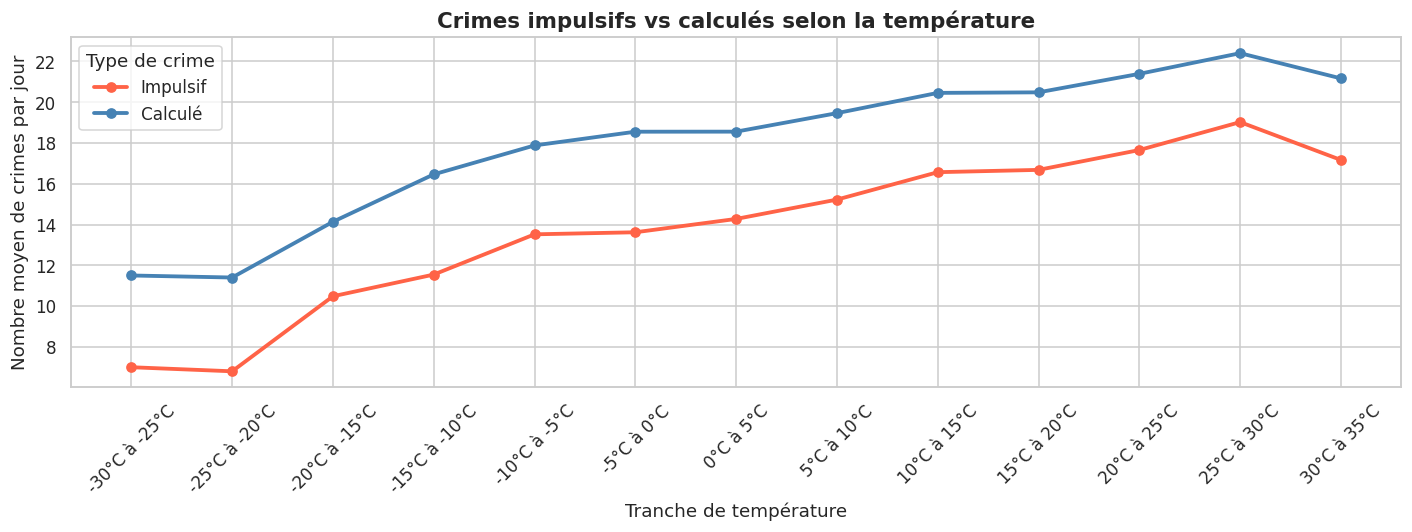

In [24]:
# uniquement les impulsifs et calculés
df_ic = df[df["crime_type"].isin(["Impulsif", "Calculé"])].copy()

daily_ic = (df_ic.groupby(["date_only", "crime_type"])
                 .agg(
                     nb_crimes=("Primary Type", "count"),
                     temp=("temperature_2m_mean (°C)", "mean")
                 )
                 .reset_index()
                 .dropna())

daily_ic["tranche"] = pd.cut(daily_ic["temp"], bins=bins, labels=labels)

seuil_ic = (daily_ic.groupby(["tranche", "crime_type"], observed=True)["nb_crimes"]
                    .mean()
                    .reset_index())
seuil_ic.columns = ["Tranche", "Type", "Moyenne crimes"]

fig, ax = plt.subplots(figsize=(13, 5))
for crime_type, color in [("Impulsif", "tomato"), ("Calculé", "steelblue")]:
    data = seuil_ic[seuil_ic["Type"] == crime_type]
    ax.plot(data["Tranche"], data["Moyenne crimes"],
            marker="o", linewidth=2.5, color=color, label=crime_type)

ax.set_title("Crimes impulsifs vs calculés selon la température",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tranche de température")
ax.set_ylabel("Nombre moyen de crimes par jour")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type de crime")

plt.tight_layout()
plt.show()

### Interprétation

**Les crimes impulsifs :**
- À -30°C : seulement 7 crimes/jour.
- Progression quasi linéaire jusqu'à 25°C–30°C où ils atteignent 19/jour.
- La courbe est fortement sensible à la température. Chaque degré
  supplémentaire augmente mécaniquement les interactions humaines
  et donc les risques de conflit.

**Les crimes calculés :**
- À -30°C : déjà 12 crimes/jour.
- La progression est beaucoup plus faible.

> La température affecte
> principalement les crimes qui dépendent de la présence humaine
> dans l'espace public et des états émotionnels.
> Un cambrioleur planifie son acte quelle que soit la météo.
> Une dispute entre voisins, elle, a besoin de chaleur pour éclater.

## 4.4 - La pluie comme bouclier

Est-ce que la pluie fait baisser les crimes ?

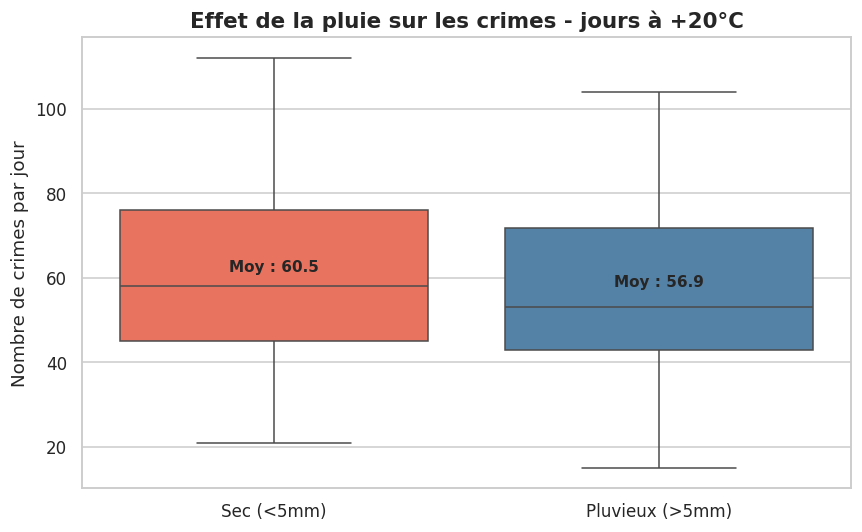

In [25]:
daily = (df.groupby("date_only")
           .agg(
               nb_crimes=("Primary Type", "count"),
               temp=("temperature_2m_mean (°C)", "mean"),
               precip=("precipitation_sum (mm)", "mean")
           )
           .reset_index()
           .dropna())

# Jours chauds uniquement (>20°C)
df_chaud = daily[daily["temp"] > 20].copy()

df_chaud["pluie"] = df_chaud["precip"].apply(
    lambda x: "Pluvieux (>5mm)" if x > 5 else "Sec (<5mm)"
)

fig, ax = plt.subplots(figsize=(8, 5))
sns.boxplot(data=df_chaud, x="pluie", y="nb_crimes",
            hue="pluie",
            palette={"Sec (<5mm)": "tomato", "Pluvieux (>5mm)": "steelblue"},
            legend=False, ax=ax)

ax.set_title("Effet de la pluie sur les crimes - jours à +20°C",
             fontsize=14, fontweight="bold")
ax.set_xlabel("")
ax.set_ylabel("Nombre de crimes par jour")

for i, groupe in enumerate(["Sec (<5mm)", "Pluvieux (>5mm)"]):
    val = df_chaud[df_chaud["pluie"] == groupe]["nb_crimes"].mean()
    ax.text(i, val + 1, f"Moy : {val:.1f}", ha="center",
            fontsize=10, fontweight="bold")

plt.tight_layout()
plt.show()

### Interprétation

La pluie a bien un effet sur les crimes, même par grande chaleur.

**Les chiffres :**
- Jours secs à +20°C : **60.5 crimes/jour** en moyenne
- Jours pluvieux à +20°C : **56.9 crimes/jour** en moyenne
- Soit une baisse de **6%** les jours de pluie

> La pluie agit comme un bouclier.
> Elle confirme que c'est bien la **présence humaine dans l'espace public**
> qui est le vrai moteur des crimes - la température l'augmente,
> la pluie la réduit légèrement. Les deux agissent sur le même mécanisme.

---

## Synthèse - Partie 4

Cette partie répond directement à notre question.

**Ce qu'on a démontré :**

1. **La corrélation température–crimes est réelle**
2. **Le seuil critique est à 5°C** : en dessous, Chicago hiberne
   criminellement. Au dessus, la ville se réveille et les crimes suivent.

3. **La distinction impulsif vs calculé est prouvée** : les crimes
   de confrontation (BATTERY, ASSAULT) sont deux fois plus sensibles
   à la température que les crimes planifiés (BURGLARY, THEFT).
   La chaleur ne rend pas les gens plus criminels - elle les met
   en contact, et les tensions font le reste.

4. **La pluie est un bouclier** : -6% de crimes les jours
   pluvieux à +20°C. La pluie
   réduit la présence humaine dans la rue, et les crimes suivent.


---

## Partie 5 - Crimes, météo et inégalités

On a montré que la météo influence les crimes à Chicago.
Mais est-ce que cet effet est le même dans tous les quartiers ?

On croise maintenant les données criminelles, la météo et
les indicateurs socioéconomiques par quartier.

## 5.1 - Portrait socioéconomique de Chicago

In [26]:
df_census = pd.read_csv("../data/Census_Data_Chicago.csv")
df_census = df_census.dropna(subset=["HARDSHIP INDEX", "Community Area Number"])
df_census["Community Area Number"] = df_census["Community Area Number"].astype(int)

# Top 5 quartiers les plus défavorisés vs les plus aisés
top_hard = df_census.nlargest(5, "HARDSHIP INDEX")[["COMMUNITY AREA NAME", "HARDSHIP INDEX", "PER CAPITA INCOME "]]
top_easy = df_census.nsmallest(5, "HARDSHIP INDEX")[["COMMUNITY AREA NAME", "HARDSHIP INDEX", "PER CAPITA INCOME "]]

print("Top 5 quartiers les plus défavorisés :")
print(top_hard.to_string(index=False))
print("\nTop 5 quartiers les plus aisés :")
print(top_easy.to_string(index=False))

Top 5 quartiers les plus défavorisés :
COMMUNITY AREA NAME  HARDSHIP INDEX  PER CAPITA INCOME 
          Riverdale            98.0                8201
        Fuller Park            97.0               10432
     South Lawndale            96.0               10402
          Englewood            94.0               11888
          Gage Park            93.0               12171

Top 5 quartiers les plus aisés :
COMMUNITY AREA NAME  HARDSHIP INDEX  PER CAPITA INCOME 
    Near North Side             1.0               88669
       Lincoln Park             2.0               71551
               Loop             3.0               65526
          Lake View             5.0               60058
       North Center             6.0               57123



- **Riverdale** : revenu per capita de 8 201$/an - Hardship Index 98/100
- **Near North Side** : revenu per capita de 88 669$/an - Hardship Index 1/100

Chicago est l'une des villes les plus inégalitaires des États-Unis,
et ces chiffres le confirment.

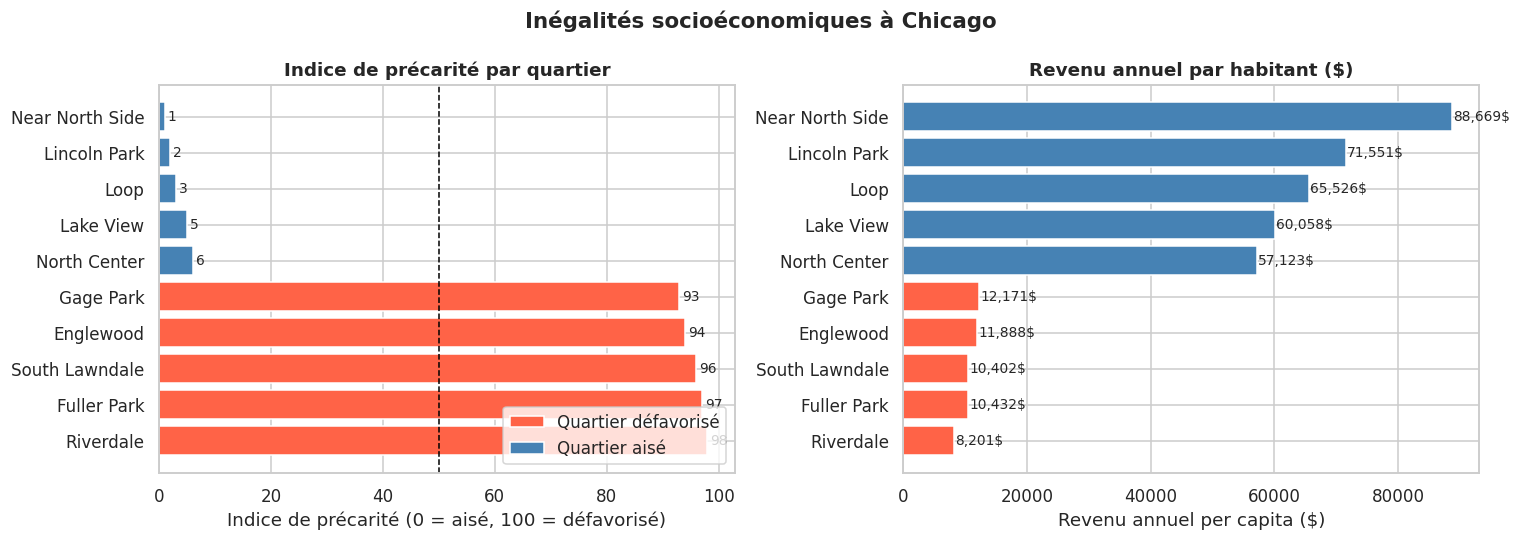

In [27]:
quartiers_focus = ["Riverdale", "Fuller Park", "South Lawndale", "Englewood", "Gage Park",
                   "Near North Side", "Lincoln Park", "Loop", "Lake View", "North Center"]

df_focus = df_census[df_census["COMMUNITY AREA NAME"].isin(quartiers_focus)].copy()
df_focus = df_focus.sort_values("HARDSHIP INDEX", ascending=False)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

colors = ["tomato" if x > 50 else "steelblue" for x in df_focus["HARDSHIP INDEX"]]

# Hardship Index
axes[0].barh(df_focus["COMMUNITY AREA NAME"], df_focus["HARDSHIP INDEX"],
             color=colors, edgecolor="white")
axes[0].set_title("Indice de précarité par quartier", fontweight="bold")
axes[0].set_xlabel("Indice de précarité (0 = aisé, 100 = défavorisé)")
axes[0].axvline(x=50, color="black", linestyle="--", linewidth=1)
for i, (val, nom) in enumerate(zip(df_focus["HARDSHIP INDEX"], df_focus["COMMUNITY AREA NAME"])):
    axes[0].text(val + 0.5, i, f"{val:.0f}", va="center", fontsize=9)

# Revenu per capita
axes[1].barh(df_focus["COMMUNITY AREA NAME"], df_focus["PER CAPITA INCOME "],
             color=colors, edgecolor="white")
axes[1].set_title("Revenu annuel par habitant ($)", fontweight="bold")
axes[1].set_xlabel("Revenu annuel per capita ($)")
for i, val in enumerate(df_focus["PER CAPITA INCOME "]):
    axes[1].text(val + 200, i, f"{val:,.0f}$", va="center", fontsize=9)

# Légende
from matplotlib.patches import Patch
legend_elements = [Patch(facecolor="tomato", label="Quartier défavorisé"),
                   Patch(facecolor="steelblue", label="Quartier aisé")]
axes[0].legend(handles=legend_elements, loc="lower right")

plt.suptitle("Inégalités socioéconomiques à Chicago", fontsize=14, fontweight="bold")
plt.tight_layout()
plt.show()

### Interprétation

Chicago est une ville de contrastes extrêmes.

**L'écart est brutal :**
- Near North Side gagne **88 669$/an** par habitant - indice de précarité : 1/100
- Riverdale gagne **8 201$/an** par habitant - indice de précarité : 98/100

Ce sont deux quartiers de la même ville, séparés de quelques kilomètres,
qui vivent dans des réalités économiques radicalement différentes.

Ces inégalités ne sont pas juste économiques; elles se traduisent
en inégalités face au risque criminel.

## 5.2 - Effet de la température selon le quartier

Est-ce que la chaleur augmente les crimes de la même façon
dans les quartiers défavorisés et dans les quartiers aisés ?

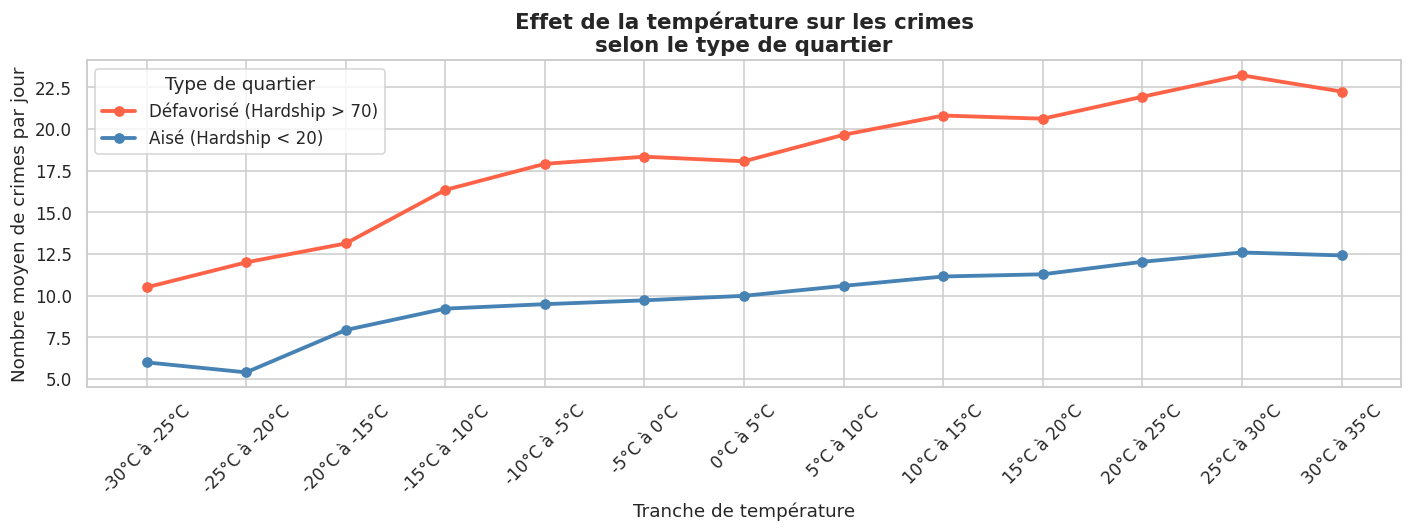

In [28]:
# Fusion crimes + census sur Community Area
df_crime_census = df.merge(
    df_census[["Community Area Number", "COMMUNITY AREA NAME",
               "HARDSHIP INDEX", "PER CAPITA INCOME "]],
    left_on="Community Area",
    right_on="Community Area Number",
    how="left"
)

# Classification des quartiers
df_crime_census["type_quartier"] = df_crime_census["HARDSHIP INDEX"].apply(
    lambda x: "Défavorisé (Hardship > 70)" if x > 70
    else ("Aisé (Hardship < 20)" if x < 20 else None)
)

df_q = df_crime_census[df_crime_census["type_quartier"].notna()].copy()

# Crimes par jour par type de quartier + température
daily_q = (df_q.groupby(["date_only", "type_quartier"])
               .agg(
                   nb_crimes=("Primary Type", "count"),
                   temp=("temperature_2m_mean (°C)", "mean")
               )
               .reset_index()
               .dropna())

daily_q["tranche"] = pd.cut(daily_q["temp"], bins=bins, labels=labels)

seuil_q = (daily_q.groupby(["tranche", "type_quartier"], observed=True)["nb_crimes"]
                  .mean()
                  .reset_index())
seuil_q.columns = ["Tranche", "Type quartier", "Moyenne crimes"]

fig, ax = plt.subplots(figsize=(13, 5))
for qtype, color in [("Défavorisé (Hardship > 70)", "tomato"),
                     ("Aisé (Hardship < 20)", "steelblue")]:
    data = seuil_q[seuil_q["Type quartier"] == qtype]
    ax.plot(data["Tranche"], data["Moyenne crimes"],
            marker="o", linewidth=2.5, color=color, label=qtype)

ax.set_title("Effet de la température sur les crimes\nselon le type de quartier",
             fontsize=14, fontweight="bold")
ax.set_xlabel("Tranche de température")
ax.set_ylabel("Nombre moyen de crimes par jour")
ax.tick_params(axis="x", rotation=45)
ax.legend(title="Type de quartier")

plt.tight_layout()
plt.show()

### Interprétation

On observe : 

**Les chiffres :**
- Par grand froid (-30°C) : les quartiers défavorisés enregistrent déjà
  **10.6 crimes/jour** contre **6.2 dans les quartiers aisés**
- Par grande chaleur (+25°C) : **23 crimes/jour** dans les quartiers défavorisés
  contre **12.8 dans les quartiers aisés**

**Ce que ça signifie :**

1. **L'écart se creuse avec la chaleur** : la température amplifie
   les inégalités existantes. Les quartiers défavorisés sont plus
   exposés au risque criminel par temps chaud que les quartiers aisés.

2. **Les quartiers aisés sont presque imperméables à la chaleur** :
   la courbe bleue progresse très peu. Lincoln Park reste relativement
   calme quelle que soit la température.

3. **Les quartiers défavorisés réagissent fortement** : la courbe rouge
   monte nettement avec la température. Englewood, Riverdale, Fuller Park
   sont directement impactés par chaque degré supplémentaire.

**Pourquoi cette différence ?**
Dans les quartiers pauvres, les gens vivent davantage dans l'espace public :
logements surpeuplés, pas de climatisation, pas de parcs privés.
La chaleur les force encore plus dehors, dans des espaces partagés
où les tensions sont déjà élevées. Dans les quartiers aisés,
la chaleur se gère à l'intérieur.

## 5.3 - Comparaison avec la littérature scientifique

### Ranson (2014) - *"Crime, weather and climate change"*

Matthew Ranson a analysé les données criminelles de 2 997 comtés
américains sur 30 ans. Son résultat principal :

> *"+2.2% de crimes violents supplémentaires par degré Celsius en plus"*

Notre projet porte sur Chicago uniquement; une ville parmi les plus
inégalitaires des USA. Est-ce que nos données confirment ce chiffre,
ou est-ce que Chicago réagit différemment ?

On calcule notre propre coefficient pour comparer.

In [29]:
# Calcul du % d'augmentation des crimes par degré supplémentaire
from scipy.stats import pearsonr, linregress

# les crimes violents uniquement (comme Ranson)
crimes_violents = ["BATTERY", "ASSAULT", "HOMICIDE", "ROBBERY"]
df_violent = df[df["Primary Type"].isin(crimes_violents)]

daily_violent = (df_violent.groupby("date_only")
                           .agg(
                               nb_crimes=("Primary Type", "count"),
                               temp=("temperature_2m_mean (°C)", "mean")
                           )
                           .reset_index()
                           .dropna())

# Régression linéaire
slope, intercept, r_value, p_value, std_err = linregress(
    daily_violent["temp"],
    daily_violent["nb_crimes"]
)

# % d'augmentation par degré
moyenne_crimes = daily_violent["nb_crimes"].mean()
pct_par_degre = (slope / moyenne_crimes) * 100

print("=" * 50)
print("  NOTRE RÉSULTAT vs RANSON 2014")
print("=" * 50)
print(f"  Ranson 2014              : +2.20%")
print(f"  Notre résultat Chicago   : {pct_par_degre:+.2f}%")
print("=" * 50)

  NOTRE RÉSULTAT vs RANSON 2014
  Ranson 2014              : +2.20%
  Notre résultat Chicago   : +1.06%


### Interprétation - Chicago vs Ranson 2014

Nos résultats confirment la direction de Ranson mais avec une intensité
différente.

**Nos chiffres :**
- **+1.06% de crimes violents par degré supplémentaire** à Chicago

**Comparaison avec Ranson 2014 :**

| | Augmentation par °C | Périmètre |
|--|--|--|
| Ranson 2014 | +2.20% | 2 997 comtés américains |
| Notre étude | +1.06% | Chicago uniquement |  

--
> **Notre résultat est cohérent avec Ranson** : la direction est la même,
> l'intensité est différente. C'est exact

---

# Limites de notre projet

**1. Échantillon de 500 000 crimes** : les chiffres exacts pourraient
varier sur le dataset complet, notamment sur les températures extrêmes
peu représentées.

**2. Données Census 2008–2012** : les inégalités sont structurellement
stables mais des évolutions récentes ne sont pas capturées.

**3. Corrélation ≠ Causalité** : d'autres facteurs jouent un rôle
(vacances, événements, politiques policières) qu'on n'a pas contrôlés.

**4. Une seule ville** : nos conclusions sont valides pour Chicago,
pas nécessairement généralisables ailleurs.

---

# Conclusion

Ce projet partait d'une question simple :
**Comment les conditions météorologiques influencent-elles la fréquence
et la nature des crimes à Chicago ?**

Ce qu'on a découvert :

- **La fréquence** : plus il fait chaud, plus il y a de crimes.
  Le seuil critique est **5°C**; en dessous, Chicago hiberne
  criminellement. À +25°C, on enregistre 125% de crimes de plus
  qu'à -30°C.

- **La nature** : tous les crimes ne réagissent pas pareil.
  Les crimes **impulsifs** (Battery, Assault) sont très sensibles
  à la chaleur. Les crimes **calculés** (Burglary, Theft) le sont
  beaucoup moins. La météo exacerbe les tensions, pas les intentions.

- **La géographie** : l'effet de la météo n'est pas le même pour
  tout le monde. À Englewood, une canicule est une menace.
  À Lincoln Park, l'effet est quasi imperceptible.

- **La science** : nos résultats confirment Ranson (2014) avec
  **+1.06% de crimes violents par degré supplémentaire** à Chicago.

> 📂 **Source** : [Chicago Crime Data — City of Chicago Open Data](https://data.cityofchicago.org/stories/s/Crimes-2001-to-present-Dashboard/5cd6-ry5g)

> 📂 **Source** : [Open-Meteo Historical Weather API — Station Chicago O'Hare](https://open-meteo.com/en/docs/historical-weather-api?latitude=41.85&longitude=-87.65&start_date=2001-01-01&end_date=2025-12-31#hourly_weather_variables)

> 📂 **Source** : [Census Data — Selected socioeconomic indicators in Chicago (2008–2012)](https://data.cityofchicago.org/Health-Human-Services/Census-Data-Selected-socioeconomic-indicators-in-C/kn9c-c2s2/about_data)

---